In [ ]:
!pip install spacy gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.0 MB/s eta 0:00:00


In [ ]:
import os
import csv
import spacy

class Corpus(object):
  def __init__(self,filename):
    self.filename=filename
    self.nlp=spacy.blank("en")

  def __iter__(self):
    with open (self.filename,"r") as i:
      reader=csv.reader(i,delimiter=",")
      for _, abstract in reader:
        tokens = [t.text.lower() for t in self.nlp(abstract)]
        yield tokens

documents = Corpus("/content/arxiv.csv")

In [ ]:
documents=list(documents)
documents[:5]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [ ]:
import gensim
model = gensim.models.Word2Vec( documents, min_count=100, window=5, vector_size=100)

In [ ]:
model.wv["nlp"]

array([ 1.7799926 , -2.538246  ,  2.5834253 , -0.85419977, -1.0116612 ,
        1.344776  ,  0.65682554,  0.7877238 , -0.6943722 ,  1.9006909 ,
       -0.32056853, -0.02116022,  1.8032248 ,  0.17405324,  0.43572575,
        1.3948541 , -0.22818327,  1.2585882 , -1.329623  ,  1.3439072 ,
        1.2793256 ,  1.2706312 ,  1.66276   ,  0.47507071, -1.0956371 ,
       -1.7433398 ,  0.98506564,  1.721131  ,  3.5379684 , -0.23670177,
        1.727905  ,  1.2660902 ,  1.0637418 ,  1.7331853 ,  0.07142029,
       -1.1210308 ,  0.04121874, -4.0056877 , -0.5767289 ,  2.2630587 ,
       -1.1718545 , -1.033164  ,  1.9027227 ,  0.37712988, -3.0058393 ,
        0.3985929 ,  1.375439  ,  0.16849943, -0.6447543 , -1.8416494 ,
        2.183233  ,  0.39503163, -0.30403256, -0.35097495,  1.7453985 ,
        0.45442668,  0.6803868 , -0.36037678,  1.2004763 , -0.47296563,
        0.58464986,  1.8087553 , -0.77216643, -0.55055   ,  1.0849663 ,
       -0.08107547, -0.2399201 , -0.7386606 ,  0.37108523, -1.25

In [ ]:
print(model.wv.similarity("same","now"))

0.06627785


In [ ]:
model.wv.similar_by_word("bert",topn=10)

[('roberta', 0.803446352481842),
 ('transformer', 0.7654328942298889),
 ('pretrained', 0.7158637642860413),
 ('elmo', 0.7092778086662292),
 ('transformers', 0.6799310445785522),
 ('xlm', 0.6507057547569275),
 ('xlnet', 0.6494807004928589),
 ('mbert', 0.6401364207267761),
 ('gpt-2', 0.6259868741035461),
 ('lstm', 0.6142382621765137)]

In [ ]:
model.wv.most_similar(positive="tree",topn=10)

[('trees', 0.7755111455917358),
 ('constituency', 0.7455928325653076),
 ('recursive', 0.7014362812042236),
 ('parse', 0.694977343082428),
 ('dependency', 0.6719211935997009),
 ('constituent', 0.6311064958572388),
 ('parser', 0.6262637376785278),
 ('syntax', 0.6067909598350525),
 ('transition', 0.5842470526695251),
 ('grammar', 0.5827172994613647)]

In [ ]:
model.wv.doesnt_match("lstm cnn gru svn tranformem",split())

'svm'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.manifold import TSNE

target_word = "bert"
selected_words = [w[0] for w in model.wv.most_similar(positive=[target_word],topn=200)] + [target_word]
embeddings = [model.wv[word] for word in selected_words]  + model.wv[target_word]

mapped_embeddings=TSNE(n_components=2,metric='cosine',init='pca', perplexity=5).fit_transform(np.vstack(embeddings))

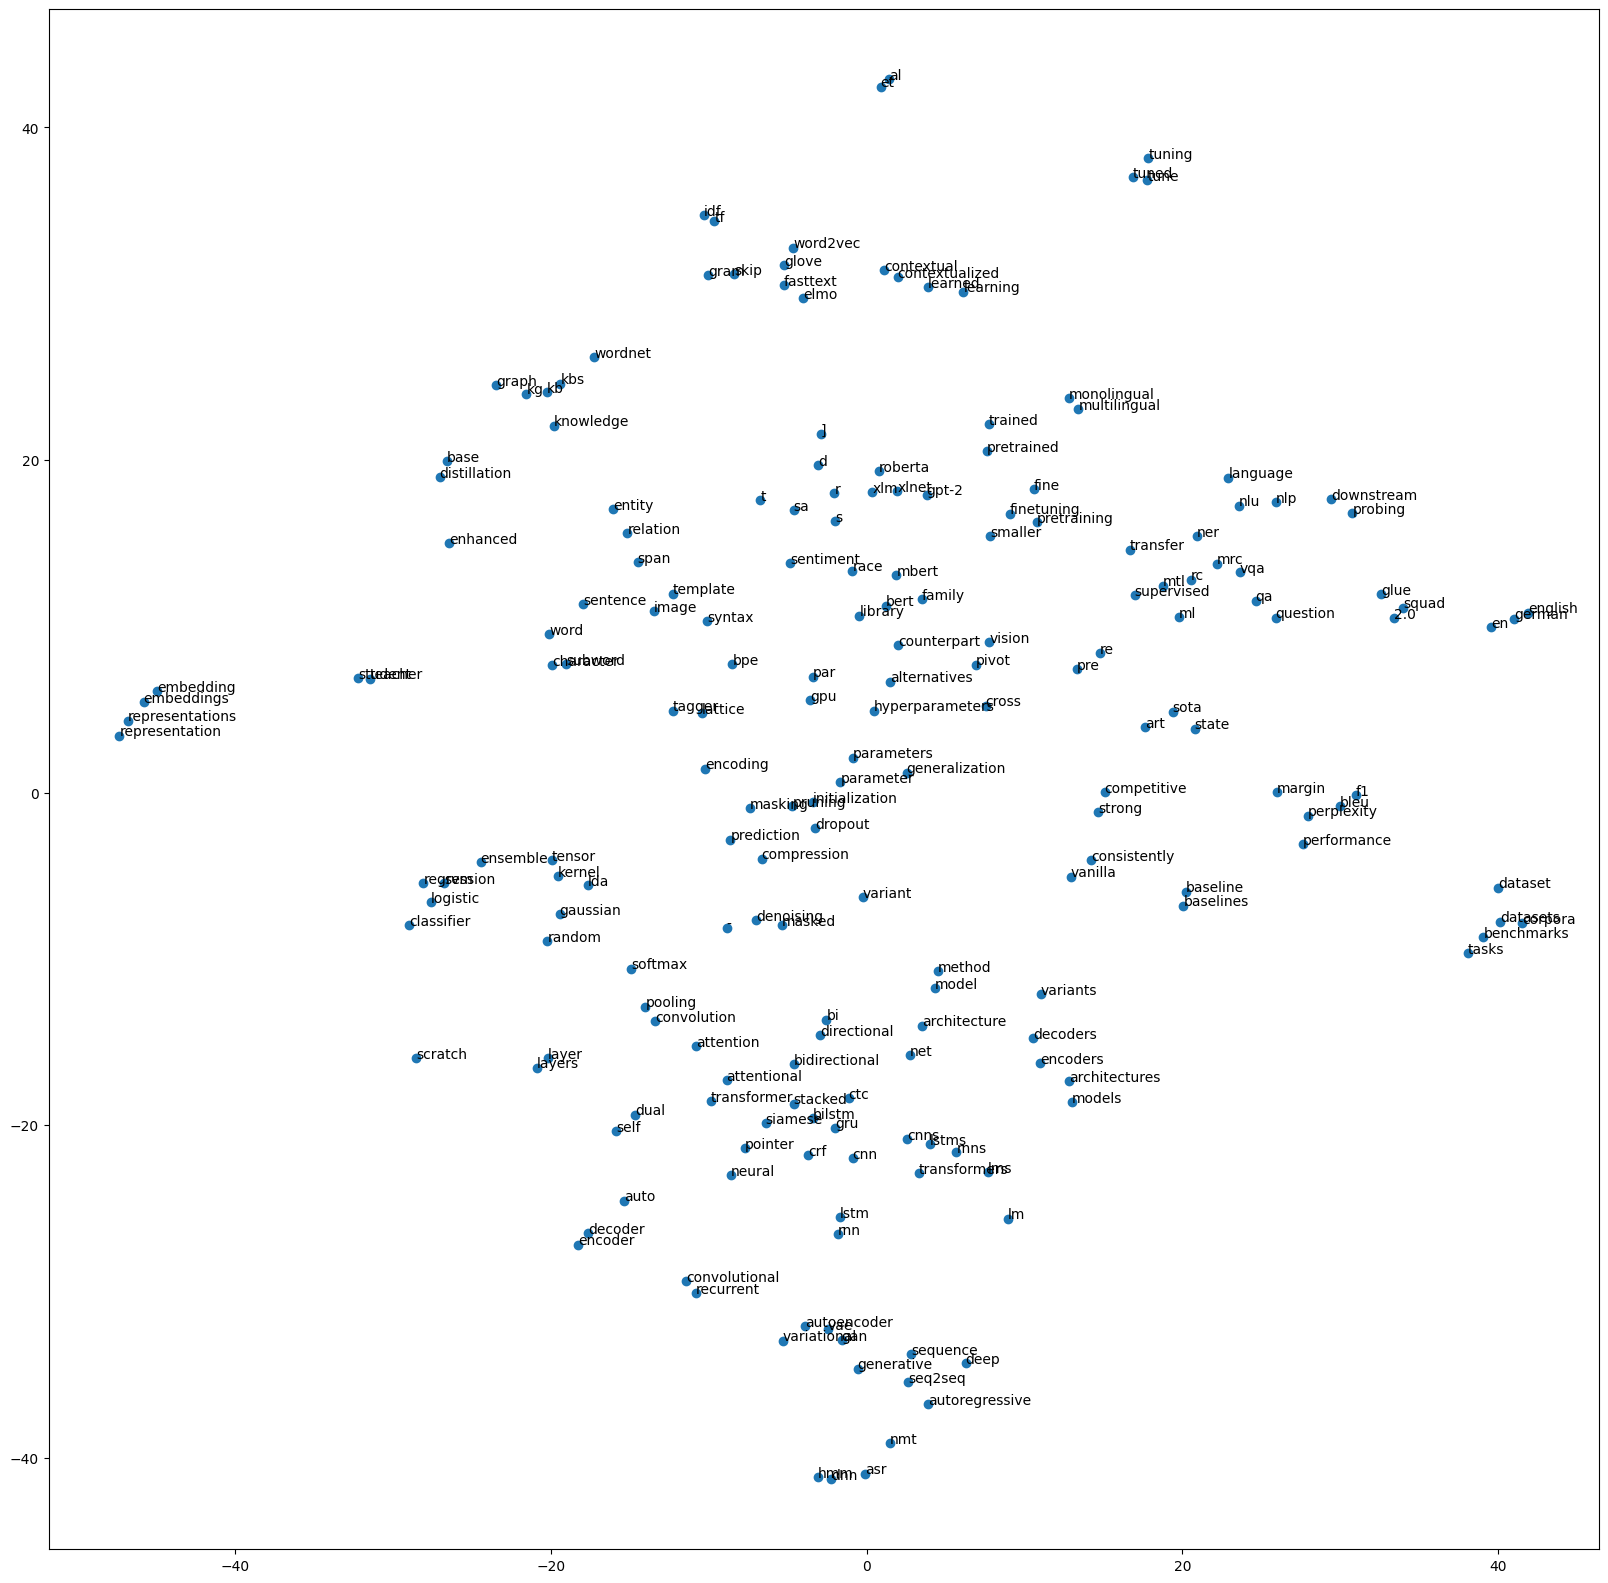

In [ ]:
plt.figure(figsize=(20,20))
x=mapped_embeddings[:,0]
y=mapped_embeddings[:,1]
plt.scatter(x,y)

for i,txt in enumerate(selected_words):
  plt.annotate(txt,(x[i],y[i]))

Similarity in sentence

In [ ]:
!pip install kaggle
!kaggle datasets download -d Cornell-University/movie-dialog-corpus

Dataset URL: https://www.kaggle.com/datasets/Cornell-University/movie-dialog-corpus
License(s): other
100% 8.91M/8.91M [00:00<00:00, 141MB/s]

